# F1 Model Training and Comparison

This notebook trains and compares different ML models for lap time prediction.

In [1]:
import sys
import os
sys.path.append(os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

from src.data_loader import load_race_data
from src.feature_engineering import preprocess_laps

# Load and preprocess data
df = load_race_data(2023, 'Monza')
features, target = preprocess_laps(df)

# Split data
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

core           INFO 	Loading data for Italian Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 1 completed the race distance 06:25.888000 before the recorded end of the session.
core        WARNING 	Driver 11 completed the race distance 06:19.824000 before the recorded end of the session.
core        WAR

Training set: 758 samples
Test set: 190 samples


Linear Regression:
  MAE: 1.7773
  RMSE: 3.4298

Random Forest:
  MAE: 1.1257
  RMSE: 3.2775



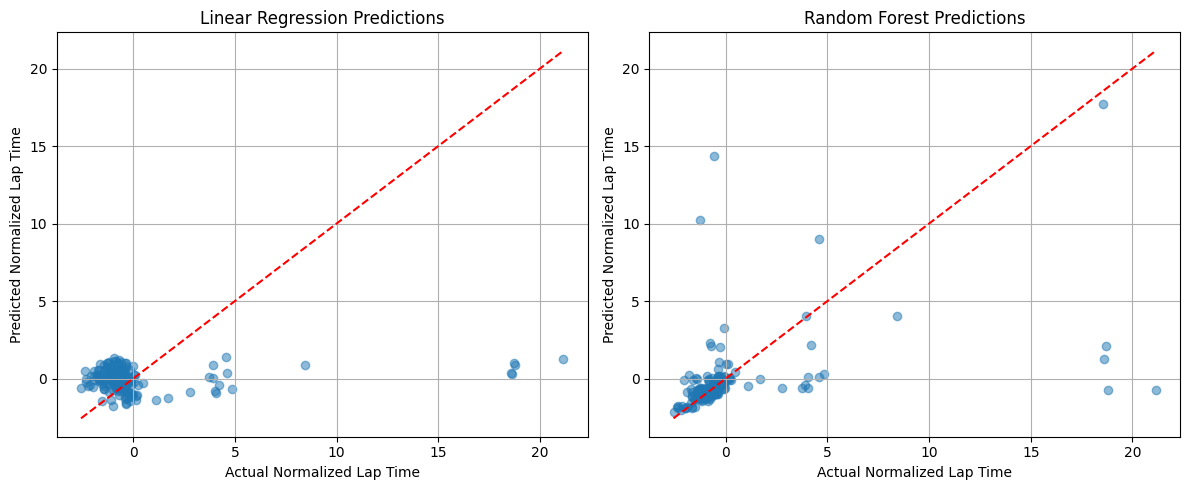

In [2]:
# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_test_scaled)

    # Evaluate
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    results[name] = {'MAE': mae, 'RMSE': rmse, 'predictions': y_pred}

    print(f"{name}:")
    print(f"  MAE: {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print()

# Plot predictions vs actual
plt.figure(figsize=(12, 5))

for i, (name, res) in enumerate(results.items()):
    plt.subplot(1, 2, i+1)
    plt.scatter(y_test, res['predictions'], alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel('Actual Normalized Lap Time')
    plt.ylabel('Predicted Normalized Lap Time')
    plt.title(f'{name} Predictions')
    plt.grid(True)

plt.tight_layout()
plt.show()

In [3]:
# Hyperparameter tuning for Random Forest
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best MAE:", -grid_search.best_score_)

# Train best model
best_rf = grid_search.best_estimator_
best_rf.fit(X_train_scaled, y_train)
y_pred_best = best_rf.predict(X_test_scaled)
mae_best = mean_absolute_error(y_test, y_pred_best)
print(f"Best model test MAE: {mae_best:.4f}")

Best parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Best MAE: 0.8770539382415671
Best model test MAE: 1.1145


Neural Network MAE: 1.2132


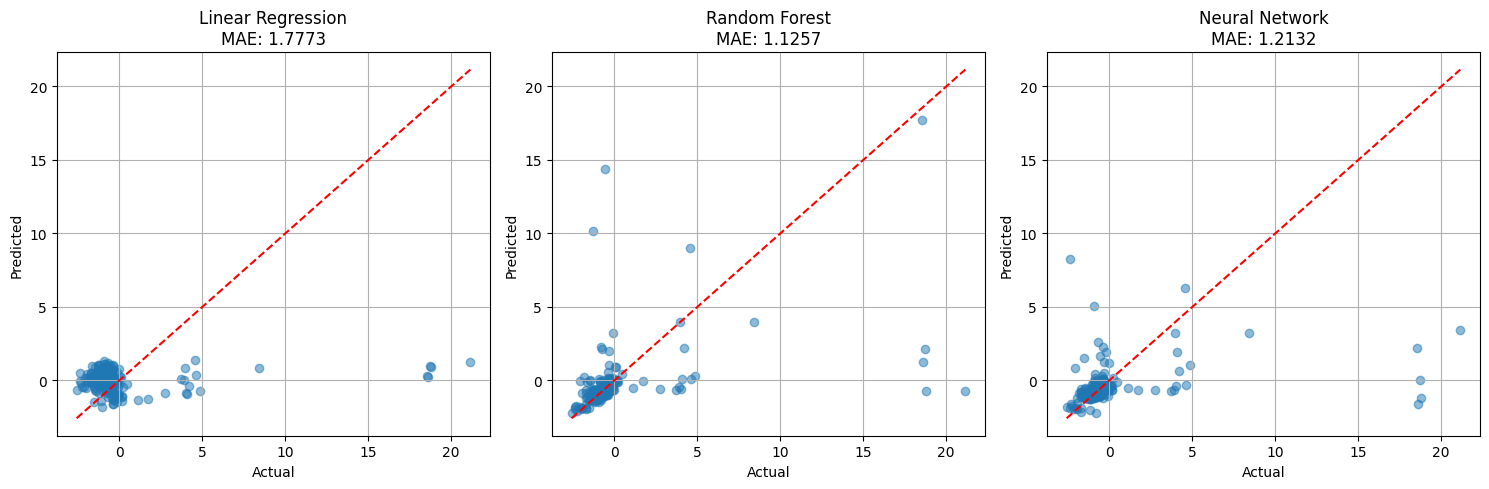

In [4]:
# Try Neural Network
from sklearn.neural_network import MLPRegressor

nn = MLPRegressor(hidden_layer_sizes=(50, 25), max_iter=1000, random_state=42)
nn.fit(X_train_scaled, y_train)
y_pred_nn = nn.predict(X_test_scaled)
mae_nn = mean_absolute_error(y_test, y_pred_nn)
print(f"Neural Network MAE: {mae_nn:.4f}")

# Update results
results['Neural Network'] = {'MAE': mae_nn, 'predictions': y_pred_nn}

# Plot all models
plt.figure(figsize=(15, 5))
model_names = list(results.keys())
for i, name in enumerate(model_names):
    plt.subplot(1, 3, i+1)
    plt.scatter(y_test, results[name]['predictions'], alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'{name}\nMAE: {results[name]["MAE"]:.4f}')
    plt.grid(True)

plt.tight_layout()
plt.show()